In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_excel("../data/raw/AirQualityUCI.xlsx",na_values=[-200, "-200"])
df.replace(-200, pd.NA, inplace=True)
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.600,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.300,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.900,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.000,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.150,59.575001,0.788794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,2005-04-04,10:00:00,3.1,1314.25,<NA>,13.529605,1101.25,471.7,538.50,189.8,1374.25,1728.50,21.850,29.250000,0.756824
9353,2005-04-04,11:00:00,2.4,1162.50,<NA>,11.355157,1027.00,353.3,603.75,179.2,1263.50,1269.00,24.325,23.725000,0.711864
9354,2005-04-04,12:00:00,2.4,1142.00,<NA>,12.374538,1062.50,293.0,603.25,174.7,1240.75,1092.00,26.900,18.350000,0.640649
9355,2005-04-04,13:00:00,2.1,1002.50,<NA>,9.547187,960.50,234.5,701.50,155.7,1041.00,769.75,28.325,13.550000,0.513866


In [2]:
df.describe()

,Date,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357,7674.000000,8991.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,2004-09-21 04:30:05.193972480,2.152750,1099.707856,10.082993,939.029205,246.881252,835.370973,113.075515,1456.143486,1022.780725,18.316054,49.232360,1.025530
min,2004-03-10 00:00:00,0.100000,647.250000,0.149048,383.250000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.175000,0.184679
25%,2004-06-16 00:00:00,1.100000,936.750000,4.436942,734.375000,98.000000,657.875000,78.000000,1226.625000,731.375000,11.787500,35.812500,0.736769
50%,2004-09-21 00:00:00,1.800000,1063.000000,8.239851,909.000000,179.800000,805.500000,109.000000,1462.750000,963.250000,17.750000,49.550000,0.995395
75%,2004-12-28 00:00:00,2.900000,1231.250000,13.988478,1116.250000,326.000000,969.250000,142.000000,1673.500000,1273.375000,24.400000,62.500001,1.313701
max,2005-04-04 00:00:00,11.900000,2039.750000,63.741476,2214.000000,1479.000000,2682.750000,339.700000,2775.000000,2522.750000,44.600000,88.725000,2.231036
std,NaN,1.453252,217.084571,7.449640,266.829000,212.971224,256.815106,48.359250,346.204540,398.480897,8.832888,17.316389,0.403813


In [3]:
df["NMHC(GT)"].unique()[:10]
df["NMHC(GT)"].dtype

dtype('O')

In [4]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           9357 non-null   datetime64[ns]
 1   Time           9357 non-null   object        
 2   CO(GT)         7674 non-null   float64       
 3   PT08.S1(CO)    8991 non-null   float64       
 4   NMHC(GT)       914 non-null    object        
 5   C6H6(GT)       8991 non-null   float64       
 6   PT08.S2(NMHC)  8991 non-null   float64       
 7   NOx(GT)        7718 non-null   float64       
 8   PT08.S3(NOx)   8991 non-null   float64       
 9   NO2(GT)        7715 non-null   float64       
 10  PT08.S4(NO2)   8991 non-null   float64       
 11  PT08.S5(O3)    8991 non-null   float64       
 12  T              8991 non-null   float64       
 13  RH             8991 non-null   float64       
 14  AH             8991 non-null   float64       
dtypes: datetime64[ns](1),

In [5]:
df_ucl_copy = df.copy()
int_cols = df_ucl_copy.select_dtypes(include=['int64']).columns
float_cols = df_ucl_copy.select_dtypes(include=['float64']).columns
df_ucl_copy[int_cols] = df_ucl_copy[int_cols].apply(pd.to_numeric, downcast='integer')
df_ucl_copy[float_cols] = df_ucl_copy[float_cols].apply(pd.to_numeric, downcast='float')

In [6]:
df_ucl_copy.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           9357 non-null   datetime64[ns]
 1   Time           9357 non-null   object        
 2   CO(GT)         7674 non-null   float32       
 3   PT08.S1(CO)    8991 non-null   float32       
 4   NMHC(GT)       914 non-null    object        
 5   C6H6(GT)       8991 non-null   float32       
 6   PT08.S2(NMHC)  8991 non-null   float32       
 7   NOx(GT)        7718 non-null   float32       
 8   PT08.S3(NOx)   8991 non-null   float32       
 9   NO2(GT)        7715 non-null   float32       
 10  PT08.S4(NO2)   8991 non-null   float32       
 11  PT08.S5(O3)    8991 non-null   float32       
 12  T              8991 non-null   float32       
 13  RH             8991 non-null   float32       
 14  AH             8991 non-null   float32       
dtypes: datetime64[ns](1),

In [7]:
df_ucl_copy.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='object')

In [8]:
df_ucl_copy['DateTime'] = pd.to_datetime(df_ucl_copy["Date"].astype(str) + ' ' + df_ucl_copy['Time'].astype(str), errors='coerce',format="%Y-%m-%d %H:%M:%S")

In [9]:
df_ucl_copy

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,DateTime
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.000000,1056.25,113.000000,1692.00,1267.50,13.600000,48.875000,0.757754,2004-03-10 18:00:00
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.000000,1173.75,92.000000,1558.75,972.25,13.300000,47.700001,0.725487,2004-03-10 19:00:00
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.000000,1140.00,114.000000,1554.50,1074.00,11.900000,53.975002,0.750239,2004-03-10 20:00:00
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.000000,1092.00,122.000000,1583.75,1203.25,11.000000,60.000000,0.786713,2004-03-10 21:00:00
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.000000,1205.00,116.000000,1490.00,1110.00,11.150000,59.575001,0.788794,2004-03-10 22:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,2005-04-04,10:00:00,3.1,1314.25,<NA>,13.529605,1101.25,471.700012,538.50,189.800003,1374.25,1728.50,21.850000,29.250000,0.756824,2005-04-04 10:00:00
9353,2005-04-04,11:00:00,2.4,1162.50,<NA>,11.355158,1027.00,353.299988,603.75,179.199997,1263.50,1269.00,24.325001,23.725000,0.711864,2005-04-04 11:00:00
9354,2005-04-04,12:00:00,2.4,1142.00,<NA>,12.374538,1062.50,293.000000,603.25,174.699997,1240.75,1092.00,26.900000,18.350000,0.640649,2005-04-04 12:00:00
9355,2005-04-04,13:00:00,2.1,1002.50,<NA>,9.547187,960.50,234.500000,701.50,155.699997,1041.00,769.75,28.324999,13.550000,0.513866,2005-04-04 13:00:00


In [10]:
df_ucl_copy.dtypes

Date             datetime64[ns]
Time                     object
CO(GT)                  float32
PT08.S1(CO)             float32
NMHC(GT)                 object
C6H6(GT)                float32
PT08.S2(NMHC)           float32
NOx(GT)                 float32
PT08.S3(NOx)            float32
NO2(GT)                 float32
PT08.S4(NO2)            float32
PT08.S5(O3)             float32
T                       float32
RH                      float32
AH                      float32
DateTime         datetime64[ns]
dtype: object

In [11]:
df_ucl_copy.drop(columns=['Date','Time'], inplace=True)

In [12]:
df_ucl_copy.dropna(how='all')

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,DateTime
0,2.6,1360.00,150,11.881723,1045.50,166.000000,1056.25,113.000000,1692.00,1267.50,13.600000,48.875000,0.757754,2004-03-10 18:00:00
1,2.0,1292.25,112,9.397165,954.75,103.000000,1173.75,92.000000,1558.75,972.25,13.300000,47.700001,0.725487,2004-03-10 19:00:00
2,2.2,1402.00,88,8.997817,939.25,131.000000,1140.00,114.000000,1554.50,1074.00,11.900000,53.975002,0.750239,2004-03-10 20:00:00
3,2.2,1375.50,80,9.228796,948.25,172.000000,1092.00,122.000000,1583.75,1203.25,11.000000,60.000000,0.786713,2004-03-10 21:00:00
4,1.6,1272.25,51,6.518224,835.50,131.000000,1205.00,116.000000,1490.00,1110.00,11.150000,59.575001,0.788794,2004-03-10 22:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,3.1,1314.25,<NA>,13.529605,1101.25,471.700012,538.50,189.800003,1374.25,1728.50,21.850000,29.250000,0.756824,2005-04-04 10:00:00
9353,2.4,1162.50,<NA>,11.355158,1027.00,353.299988,603.75,179.199997,1263.50,1269.00,24.325001,23.725000,0.711864,2005-04-04 11:00:00
9354,2.4,1142.00,<NA>,12.374538,1062.50,293.000000,603.25,174.699997,1240.75,1092.00,26.900000,18.350000,0.640649,2005-04-04 12:00:00
9355,2.1,1002.50,<NA>,9.547187,960.50,234.500000,701.50,155.699997,1041.00,769.75,28.324999,13.550000,0.513866,2005-04-04 13:00:00


In [13]:
df_ucl_copy.describe()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,DateTime
count,7674.00000,8991.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,9357
mean,2.15275,1099.707764,10.082993,939.029236,246.881256,835.370911,113.075516,1456.143433,1022.780640,18.316055,49.232361,1.025530,2004-09-21 16:00:00
min,0.10000,647.250000,0.149048,383.250000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.175000,0.184679,2004-03-10 18:00:00
25%,1.10000,936.750000,4.436942,734.375000,98.000000,657.875000,78.000000,1226.625000,731.375000,11.787500,35.812500,0.736769,2004-06-16 05:00:00
50%,1.80000,1063.000000,8.239851,909.000000,179.800003,805.500000,109.000000,1462.750000,963.250000,17.750000,49.549999,0.995395,2004-09-21 16:00:00
75%,2.90000,1231.250000,13.988478,1116.250000,326.000000,969.250000,142.000000,1673.500000,1273.375000,24.400000,62.500000,1.313701,2004-12-28 03:00:00
max,11.90000,2039.750000,63.741478,2214.000000,1479.000000,2682.750000,339.700012,2775.000000,2522.750000,44.600002,88.724998,2.231036,2005-04-04 14:00:00
std,1.45326,217.084641,7.449648,266.828857,212.971237,256.814911,48.359291,346.204742,398.480621,8.832889,17.316393,0.403813,NaN


In [39]:
import os
PROCESSED_DATA_DIR = '../data/processed/'
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
df_ucl_copy['DateTime'].dt.tz_localize('UTC')

In [15]:
# time coverage
date_range = pd.date_range(start=df_ucl_copy['DateTime'].min(), end=df_ucl_copy['DateTime'].max(), freq='D')
missing_dates = date_range.difference(df_ucl_copy['DateTime'])

len(missing_dates)

0

# MISSING VALUES UCL

In [16]:
(df_ucl_copy == -200).sum()

CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
DateTime         0
dtype: int64

In [17]:
df_ucl_copy.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CO(GT)         7674 non-null   float32       
 1   PT08.S1(CO)    8991 non-null   float32       
 2   NMHC(GT)       914 non-null    object        
 3   C6H6(GT)       8991 non-null   float32       
 4   PT08.S2(NMHC)  8991 non-null   float32       
 5   NOx(GT)        7718 non-null   float32       
 6   PT08.S3(NOx)   8991 non-null   float32       
 7   NO2(GT)        7715 non-null   float32       
 8   PT08.S4(NO2)   8991 non-null   float32       
 9   PT08.S5(O3)    8991 non-null   float32       
 10  T              8991 non-null   float32       
 11  RH             8991 non-null   float32       
 12  AH             8991 non-null   float32       
 13  DateTime       9357 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float32(12), object(1)
memory usage: 1005.7 KB


In [18]:
total_miss = df_ucl_copy.isna().sum().sort_values(ascending=False)
percent_miss = (df_ucl_copy.isna().sum()/df_ucl_copy.isna().count()).sort_values(ascending=False)
dataset_miss = pd.concat(objs=[total_miss,percent_miss], keys=['Total','Percent'], axis=1)
dataset_miss

,Total,Percent
NMHC(GT),8443,0.902319
CO(GT),1683,0.179865
NO2(GT),1642,0.175484
NOx(GT),1639,0.175163
PT08.S1(CO),366,0.039115
C6H6(GT),366,0.039115
PT08.S2(NMHC),366,0.039115
PT08.S3(NOx),366,0.039115
PT08.S4(NO2),366,0.039115
PT08.S5(O3),366,0.039115


# Missing chart

Text(0, 0.5, 'Phần trăm')

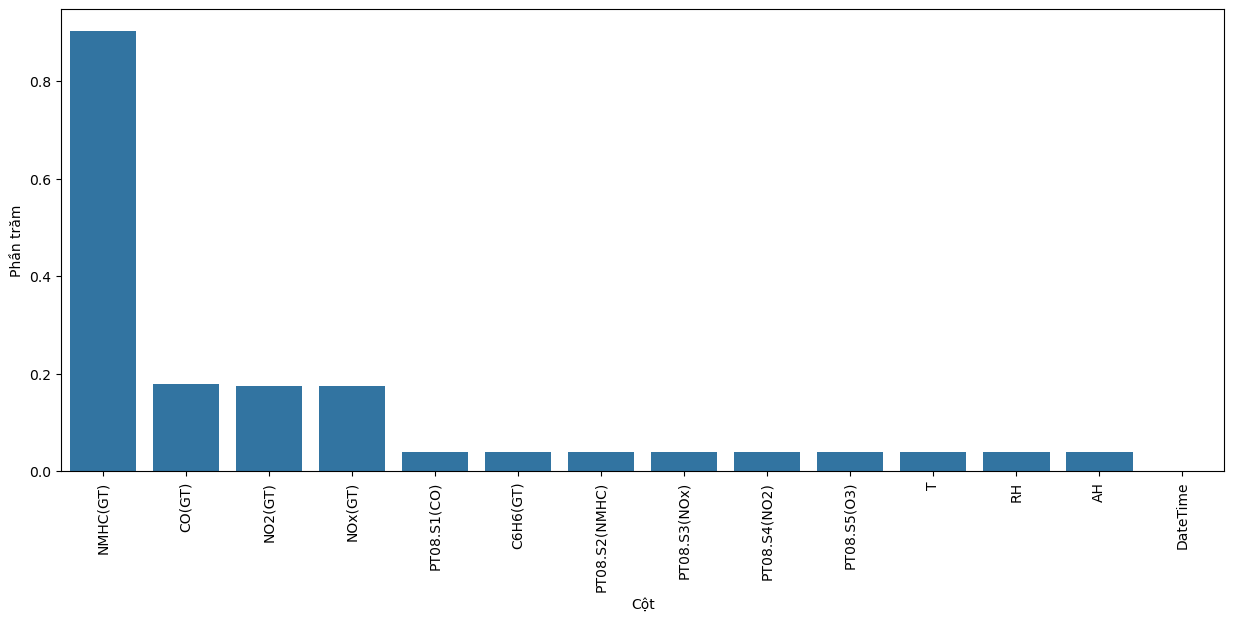

In [19]:
f, ax = plt.subplots(figsize=(15,6))
plt.xticks(rotation='vertical')
sns.barplot(x=dataset_miss.index, y= dataset_miss['Percent'].values)
plt.xlabel('Cột')
plt.ylabel('Phần trăm')

<Axes: >

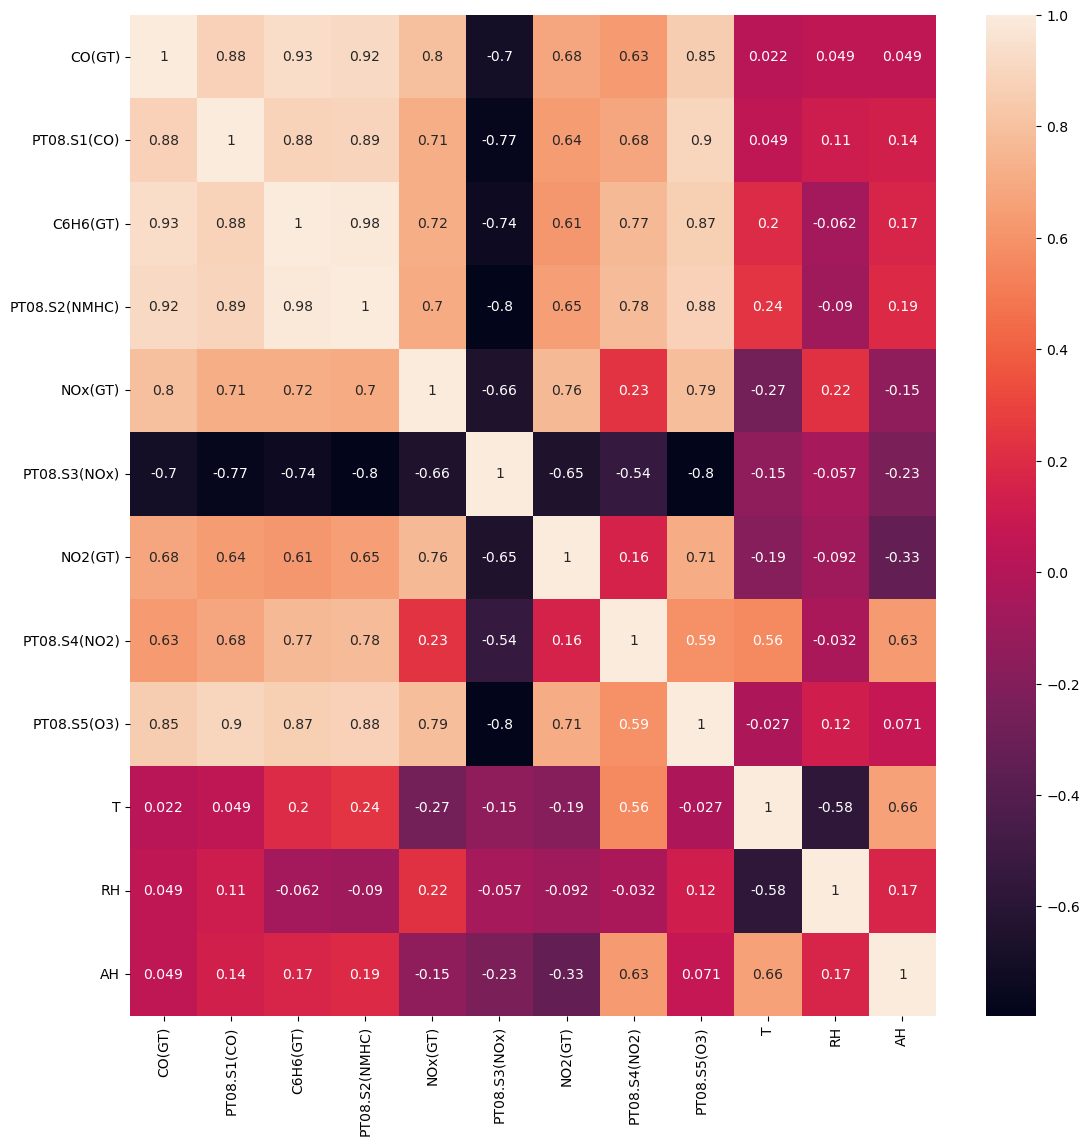

In [20]:
df_numeric = df_ucl_copy.select_dtypes(include=np.number)
plt.figure(figsize=(13,13))
sns.heatmap(df_numeric.corr(), annot=True)

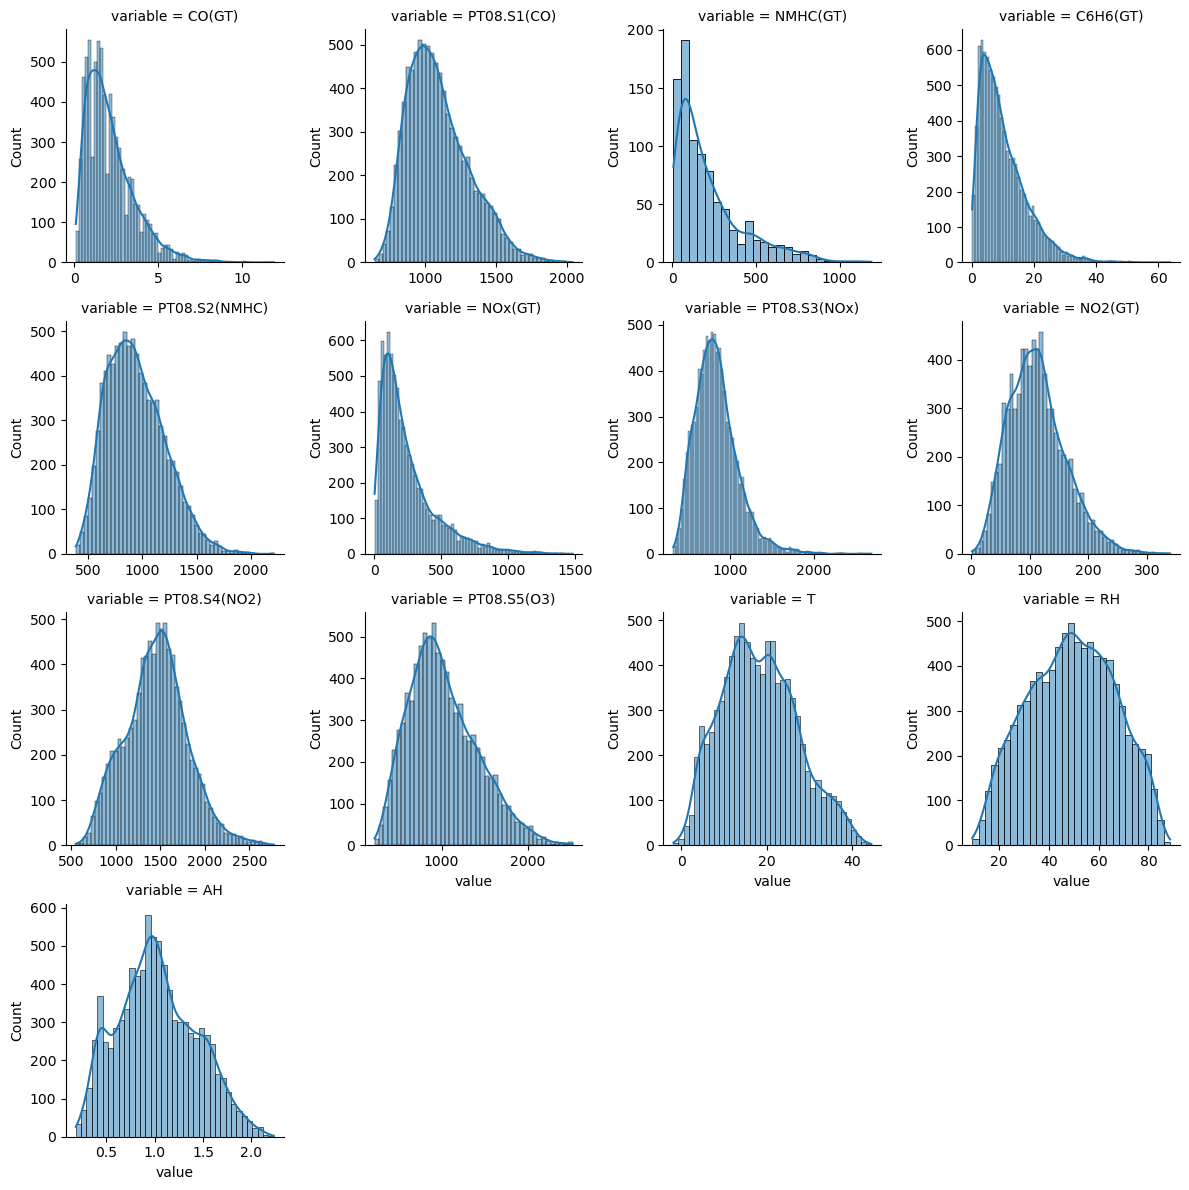

In [21]:
df_melt = df_ucl_copy.melt(value_vars=['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'])

g = sns.FacetGrid(df_melt, col="variable", col_wrap=4, sharex=False, sharey=False)
g.map(sns.histplot, "value", kde=True)

plt.show()

In [22]:
df_global = pd.read_csv('../data/raw/Air_Quality.csv')
df_global.head()

,Date,City,CO,NO2,SO2,O3,PM2.5,PM10,AQI
0,2025-01-01 00:00:00+00:00,Brasilia,325.0,21.1,2.5,35.0,15.4,15.6,20.483337
1,2025-01-01 01:00:00+00:00,Brasilia,369.0,20.8,2.7,35.0,15.1,15.3,20.425000
2,2025-01-01 02:00:00+00:00,Brasilia,419.0,20.4,3.0,34.0,15.6,15.8,20.333332
3,2025-01-01 03:00:00+00:00,Brasilia,451.0,20.5,3.1,33.0,16.4,16.6,20.258335
4,2025-01-01 04:00:00+00:00,Brasilia,458.0,22.1,3.0,29.0,17.7,17.8,20.316668


In [23]:

df_global.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52560 entries, 0 to 52559
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    52560 non-null  object 
 1   City    52560 non-null  object 
 2   CO      52560 non-null  float64
 3   NO2     52560 non-null  float64
 4   SO2     52560 non-null  float64
 5   O3      52560 non-null  float64
 6   PM2.5   52560 non-null  float64
 7   PM10    52560 non-null  float64
 8   AQI     52560 non-null  float64
dtypes: float64(7), object(2)
memory usage: 3.6+ MB


In [24]:
df_global.describe()

,CO,NO2,SO2,O3,PM2.5,PM10,AQI
count,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000
mean,245.269711,24.129863,15.485135,64.416267,17.246579,28.553288,41.236672
std,146.926588,19.323853,24.794611,35.054135,15.429194,36.877058,22.740643
min,52.000000,0.000000,0.300000,0.000000,0.000000,0.000000,7.600000
25%,155.000000,9.400000,1.900000,41.000000,5.800000,7.600000,23.600002
50%,206.000000,18.900000,5.200000,60.000000,11.900000,14.400000,33.475001
75%,288.000000,33.700000,20.400000,84.000000,23.500000,33.900000,59.949994
max,1621.000000,127.100000,478.000000,288.000000,104.300000,470.300000,152.248350


In [25]:
#downcast type
int_cols = df_global.select_dtypes(include=['int64']).columns
float_cols = df_global.select_dtypes(include=['float64']).columns
df_global[int_cols] = df_global[int_cols].apply(pd.to_numeric, downcast='integer')
df_global[float_cols] = df_global[float_cols].apply(pd.to_numeric, downcast='float')

In [26]:
df_global.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52560 entries, 0 to 52559
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    52560 non-null  object 
 1   City    52560 non-null  object 
 2   CO      52560 non-null  float32
 3   NO2     52560 non-null  float32
 4   SO2     52560 non-null  float32
 5   O3      52560 non-null  float32
 6   PM2.5   52560 non-null  float32
 7   PM10    52560 non-null  float32
 8   AQI     52560 non-null  float32
dtypes: float32(7), object(2)
memory usage: 7.9 MB


In [27]:
df_global.isna().sum()

Date     0
City     0
CO       0
NO2      0
SO2      0
O3       0
PM2.5    0
PM10     0
AQI      0
dtype: int64

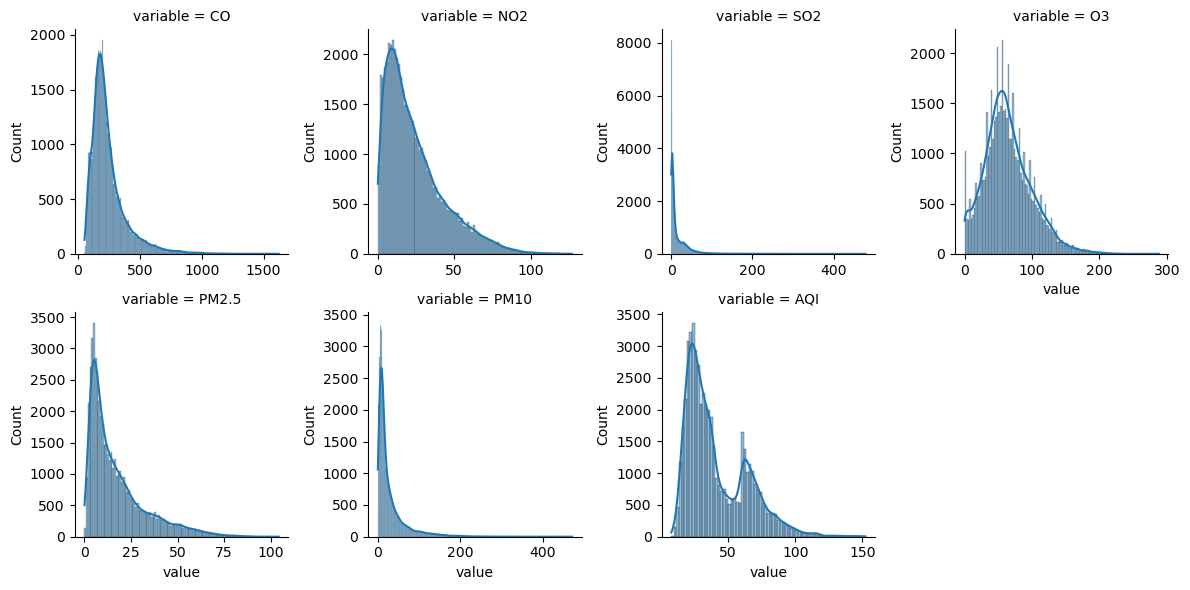

<Axes: ylabel='CO'>

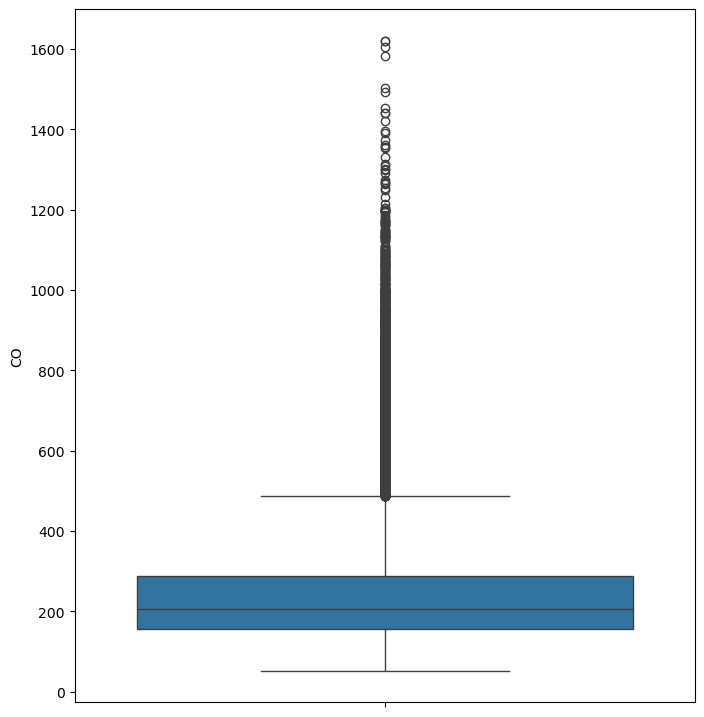

In [28]:
df_numeric = df_global.melt(value_vars=['CO','NO2','SO2','O3','PM2.5','PM10','AQI'])

g = sns.FacetGrid(df_numeric, col="variable", col_wrap=4, sharex=False, sharey=False)
g.map(sns.histplot, "value", kde=True)
plt.show()
plt.figure(figsize=(8,9))
plt.xticks(rotation='vertical')
sns.boxplot(data=df_global['CO'])
#full lệch phải

# Bias

<Axes: xlabel='City', ylabel='COunt'>

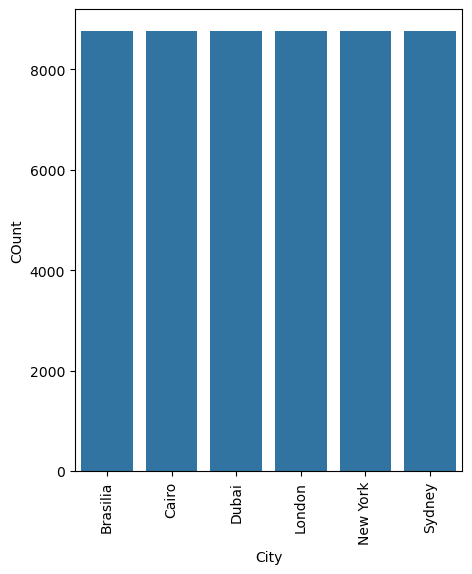

In [29]:
# file UCL
df_group_city = df_global['City'].value_counts()
plt.figure(figsize=(5,6))
plt.ylabel('COunt')
plt.xlabel('City')
plt.xticks(rotation='vertical')
sns.barplot(df_group_city)

<Axes: ylabel='City'>

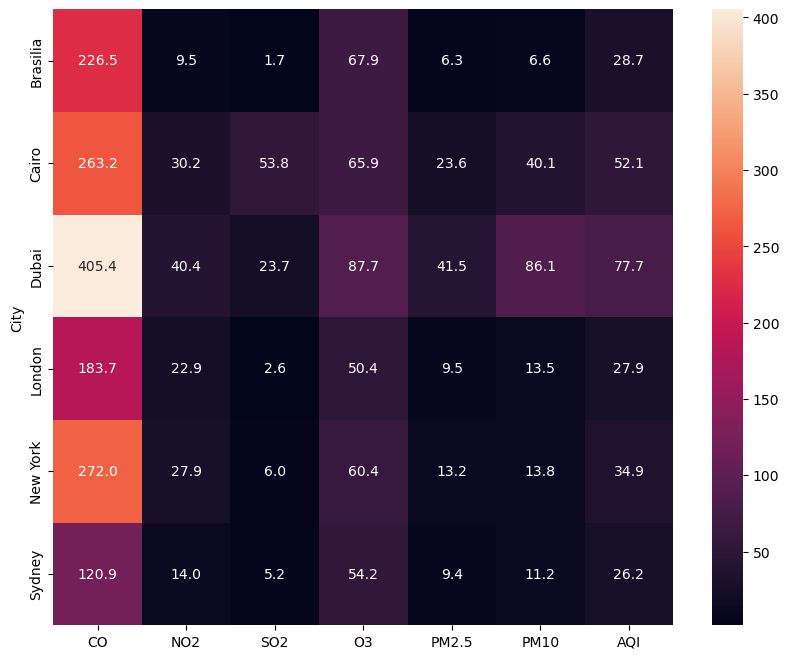

In [30]:
df_column_numeric = df_global.select_dtypes(include=[np.number]).columns
analysis_data = df_global.groupby(by=['City'])[df_column_numeric].mean()
plt.figure(figsize=(10,8))
sns.heatmap(analysis_data,fmt=".1f",annot=True)

# Lưu file parquet

In [31]:
df_ucl_copy.set_index('DateTime', inplace=True)
df_ucl_copy.sort_index(inplace=True)

In [32]:
processed_uci_path = os.path.join(PROCESSED_DATA_DIR, 'uci_air_quality_cleaned.parquet')
df_ucl_copy.to_parquet(processed_uci_path, index=True)
df_ucl_copy.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9357 entries, 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         7674 non-null   float32
 1   PT08.S1(CO)    8991 non-null   float32
 2   NMHC(GT)       914 non-null    object 
 3   C6H6(GT)       8991 non-null   float32
 4   PT08.S2(NMHC)  8991 non-null   float32
 5   NOx(GT)        7718 non-null   float32
 6   PT08.S3(NOx)   8991 non-null   float32
 7   NO2(GT)        7715 non-null   float32
 8   PT08.S4(NO2)   8991 non-null   float32
 9   PT08.S5(O3)    8991 non-null   float32
 10  T              8991 non-null   float32
 11  RH             8991 non-null   float32
 12  AH             8991 non-null   float32
dtypes: float32(12), object(1)
memory usage: 1005.6 KB


In [33]:
processed_global_path = os.path.join(PROCESSED_DATA_DIR, 'global_air_quality.parquet')
df_global.to_parquet(processed_global_path)

# Triển khai thêm cho tặp dữ liệu của Hà Nội

In [29]:
df_hanoi = pd.read_csv("../data/raw/hanoi-air-quality.csv")
df_hanoi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3488 entries, 0 to 3487
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    3488 non-null   object
 1   pm25    3488 non-null   object
 2   pm10    3488 non-null   object
 3   o3      3488 non-null   object
 4   no2     3488 non-null   object
 5   so2     3488 non-null   object
 6   co      3488 non-null   object
dtypes: object(7)
memory usage: 190.9+ KB


In [30]:
df_hanoi.describe()

,date,pm25,pm10,o3,no2,so2,co
count,3488,3488,3488,3488,3488,3488,3488
unique,3488,207,128,117,60,49,68
top,3/1/2026,,,,,,
freq,1,276,275,670,582,575,649


In [31]:
cols = ['pm25', 'pm10', 'o3', 'no2', 'so2', 'co']
df_hanoi[cols] = df_hanoi[cols].apply(pd.to_numeric, errors='coerce')
df_hanoi.columns

Index(['date', 'pm25', 'pm10', 'o3', 'no2', 'so2', 'co'], dtype='object')

In [32]:
df_hanoi.describe()

,pm25,pm10,o3,no2,so2,co
count,3212.000000,3213.000000,2818.000000,2906.000000,2913.000000,2839.000000
mean,75.525218,42.085590,17.716466,16.972471,11.729832,10.911236
std,43.990652,23.152961,22.333869,11.073806,7.561660,9.376128
min,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,41.000000,24.000000,8.000000,9.000000,6.000000,6.000000
50%,68.000000,40.000000,13.000000,16.000000,10.000000,8.000000
75%,104.000000,56.000000,21.000000,25.000000,15.000000,12.000000
max,299.000000,187.000000,498.000000,75.000000,52.000000,102.000000


In [33]:
df_hanoi.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3488 entries, 0 to 3487
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    3488 non-null   object 
 1   pm25    3212 non-null   float64
 2   pm10    3213 non-null   float64
 3   o3      2818 non-null   float64
 4   no2     2906 non-null   float64
 5   so2     2913 non-null   float64
 6   co      2839 non-null   float64
dtypes: float64(6), object(1)
memory usage: 361.1 KB


In [34]:
percent_missing = df_hanoi.apply(lambda x: x.isna().sum() / x.isna().count())
percent_missing

date    0.000000
pm25    0.079128
pm10    0.078842
o3      0.192087
no2     0.166858
so2     0.164851
co      0.186067
dtype: float64

Text(0, 0.5, 'Phần trăm')

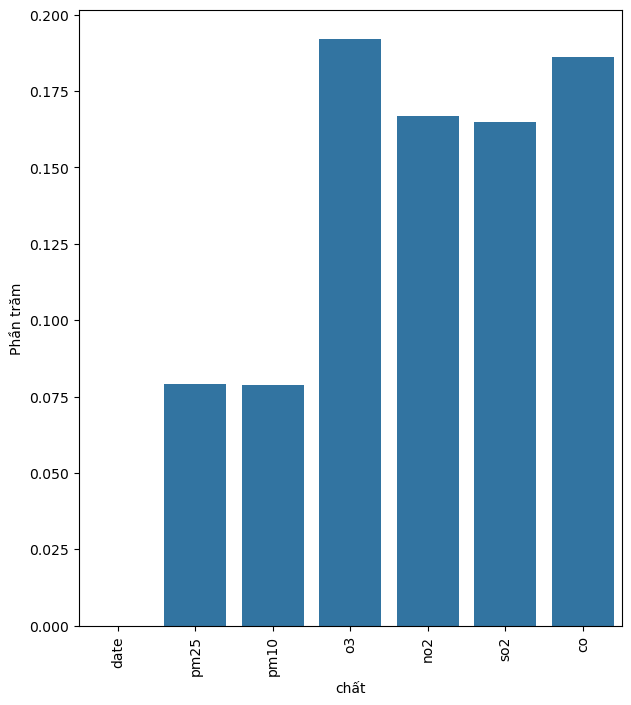

In [37]:
plt.figure(figsize=(7,8))
plt.xticks(rotation='vertical')
sns.barplot(x=percent_missing.index, y=percent_missing.values)
plt.xlabel('chất')
plt.ylabel('Phần trăm')

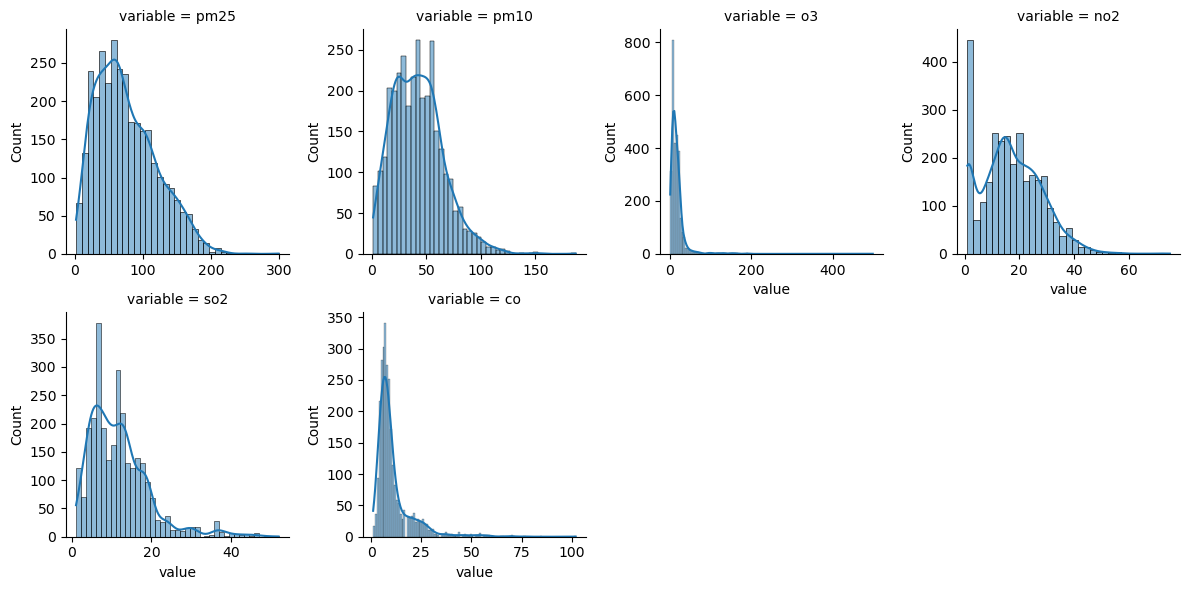

In [38]:
df_hanoi_numeric = df_hanoi.melt(value_vars=['pm25', 'pm10', 'o3', 'no2', 'so2', 'co'])

g = sns.FacetGrid(df_hanoi_numeric, col="variable", col_wrap=4, sharex=False, sharey=False)
g.map(sns.histplot, "value", kde=True)
plt.show()
# plt.figure(figsize=(8,9))
# plt.xticks(rotation='vertical')
# sns.boxplot(data=df_global['CO'])

In [40]:
processed_hanoi_path = os.path.join(PROCESSED_DATA_DIR, 'hanoi_air_quality_cleaned.parquet')
df_hanoi.to_parquet(processed_hanoi_path, index=True)
df_hanoi.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3488 entries, 0 to 3487
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    3488 non-null   object 
 1   pm25    3212 non-null   float64
 2   pm10    3213 non-null   float64
 3   o3      2818 non-null   float64
 4   no2     2906 non-null   float64
 5   so2     2913 non-null   float64
 6   co      2839 non-null   float64
dtypes: float64(6), object(1)
memory usage: 361.1 KB


In [41]:
df_hanoi.head()

,date,pm25,pm10,o3,no2,so2,co
0,3/1/2026,53.0,42.0,NaN,NaN,NaN,NaN
1,3/2/2026,64.0,28.0,NaN,NaN,NaN,NaN
2,3/3/2026,31.0,36.0,NaN,NaN,NaN,NaN
3,3/4/2026,53.0,61.0,NaN,NaN,NaN,NaN
4,3/5/2026,81.0,81.0,NaN,NaN,NaN,NaN
